# Graph-based analysis of the COMMUTE KGs

In [1]:
%store -r

In [2]:
import commute_dm.utils
import credentials
import momapy_kb.lpg.backends.neo4j
import momapy_kb.lpg.session
import pandas as pd

In [3]:
def stripe_table(dataframe, column_colors=(None, "#d6eaf8"), row_color="#c5e0f5"):
    """Return a Styler with column-wise striping that cycles through
    ``column_colors`` (one hue per column, wrapping around), then row-wise grey
    striping on top; where an odd row meets a coloured column the two shades are
    blended. Pass more than two ``column_colors`` to group columns (e.g. one hue
    per in/out/total degree)."""

    def blend(first, second):
        if first is None:
            return second
        if second is None:
            return first
        channels = (
            (int(first[i : i + 2], 16) + int(second[i : i + 2], 16)) // 2
            for i in (1, 3, 5)
        )
        return "#" + "".join(f"{channel:02x}" for channel in channels)

    def shade(data):
        styles = pd.DataFrame("", index=data.index, columns=data.columns)
        for row_position in range(len(data.index)):
            for column_position in range(len(data.columns)):
                color = column_colors[column_position % len(column_colors)]
                if row_position % 2 == 1:
                    color = blend(color, row_color)
                if color:
                    styles.iat[row_position, column_position] = (
                        f"background-color: {color}"
                    )
        return styles

    return dataframe.style.apply(shade, axis=None).format(precision=2)

In [4]:
backend = momapy_kb.lpg.backends.neo4j.Neo4jBackend(
    hostname=credentials.NEO4J_URI,
    username=credentials.NEO4J_USERNAME,
    password=credentials.NEO4J_PASSWORD,
    notifications_min_severity="off",
)
session = momapy_kb.lpg.session.Session(backend)

In [5]:
BEL_COLLECTIONS = ["AD_KG_BEL", "CBM_KG_BEL", "COVID_KG_BEL", "PD_KG_BEL"]
CD_COLLECTIONS = ["COVID_DM_CD", "PD_DM_CD", "COVID_DM_CD_AF", "PD_DM_CD_AF"]

## Overview of all collections

In [6]:
def get_collections_overview(session):
    """One row per collection: the modelling language (CellDesigner or BEL), the
    number of its constituent submodels (disease maps for CellDesigner
    collections, thematic BEL subgraphs for BEL collections), and the total
    number of nodes and relationships stored under the collection.
    """
    query = """
        MATCH (collection:Collection)
        WHERE collection.name IN $collection_names
        OPTIONAL MATCH (collection)-[:HAS_ENTRY]->(entry:CollectionEntry)
        OPTIONAL MATCH (entry)-[:HAS_OBJ]->(celldesigner_map:CellDesignerMap)
        OPTIONAL MATCH (entry)-[:HAS_OBJ]->(:BELModel)-[:HAS_SUBGRAPH]->(subgraph:Subgraph)
        WITH
            collection,
            count(DISTINCT entry) AS n_entries,
            count(DISTINCT celldesigner_map) AS n_celldesigner_maps,
            count(DISTINCT subgraph) AS n_subgraphs
        CALL apoc.path.subgraphAll(collection, {maxLevel: -1, relationshipFilter: ">"})
            YIELD nodes, relationships
        RETURN
            collection.name AS collection_name,
            CASE WHEN n_celldesigner_maps > 0
                THEN "CellDesigner" ELSE "BEL" END AS language,
            CASE WHEN n_celldesigner_maps > 0
                THEN n_entries ELSE n_subgraphs END AS n_maps_or_subgraphs,
            size(nodes) AS n_nodes,
            size(relationships) AS n_relationships
        ORDER BY n_nodes DESC
    """
    result_rows = session.execute_query(
        query, params={"collection_names": CD_COLLECTIONS + BEL_COLLECTIONS}
    )
    dataframe = pd.DataFrame(
        [dict(row) for row in result_rows],
        columns=[
            "collection_name",
            "language",
            "n_maps_or_subgraphs",
            "n_nodes",
            "n_relationships",
        ],
    )
    dataframe["n_relationships_per_node"] = (
        dataframe["n_relationships"] / dataframe["n_nodes"]
    ).round(2)
    return dataframe.sort_values("n_nodes", ascending=False).reset_index(drop=True)

In [7]:
overview_df = get_collections_overview(session)
stripe_table(overview_df)

,collection_name,language,n_maps_or_subgraphs,n_nodes,n_relationships,n_relationships_per_node
0,PD_DM_CD,CellDesigner,40,294564,753672,2.56
1,PD_DM_CD_AF,CellDesigner,40,163026,420449,2.58
2,COVID_DM_CD,CellDesigner,22,126330,338020,2.68
3,COVID_DM_CD_AF,CellDesigner,22,44438,115545,2.60
4,CBM_KG_BEL,BEL,1,12753,50111,3.93
5,COVID_KG_BEL,BEL,1,10327,43078,4.17
6,PD_KG_BEL,BEL,66,7530,34723,4.61
7,AD_KG_BEL,BEL,124,5151,28825,5.60


## CD DMs

### Overview

In [8]:
def get_cd_collections_overview(session):
    """One row per CellDesigner collection: the total number of species,
    reactions, modulations and compartments, summed across all of the
    collection's disease maps."""
    query = """
        MATCH (collection:Collection)-[:HAS_ENTRY]->(:CollectionEntry)
            -[:HAS_OBJ]->(:CellDesignerMap)-[:HAS_MODEL]->(:CellDesignerModel)
            -[:HAS_MODEL_ELEMENT]->(model_element)
        WHERE collection.name IN $cd_collections
        RETURN
            collection.name AS collection_name,
            sum(CASE WHEN model_element:Species THEN 1 ELSE 0 END) AS n_species,
            sum(CASE WHEN model_element:Reaction THEN 1 ELSE 0 END) AS n_reactions,
            sum(CASE WHEN model_element:Modulation THEN 1 ELSE 0 END) AS n_modulations,
            sum(CASE WHEN model_element:Compartment THEN 1 ELSE 0 END) AS n_compartments
        ORDER BY n_species DESC
    """
    result_rows = session.execute_query(
        query, params={"cd_collections": CD_COLLECTIONS}
    )
    dataframe = pd.DataFrame(
        [dict(row) for row in result_rows],
        columns=[
            "collection_name",
            "n_species",
            "n_reactions",
            "n_modulations",
            "n_compartments",
        ],
    )
    return dataframe.sort_values("n_species", ascending=False).reset_index(drop=True)

In [9]:
cd_overview_df = get_cd_collections_overview(session)
stripe_table(cd_overview_df)

,collection_name,n_species,n_reactions,n_modulations,n_compartments
0,PD_DM_CD,6996,1561,2338,534
1,PD_DM_CD_AF,4477,0,3836,374
2,COVID_DM_CD,3864,1221,174,136
3,COVID_DM_CD_AF,1540,0,1094,120


### Species breakdown by type

In [10]:
def get_cd_collections_species_breakdown(session):
    """Number of species of each CellDesigner species type (Protein, Complex,
    SimpleMolecule, RNA, Gene, ...), one row per type and one column per
    CellDesigner collection, each followed by a "%<collection>" column giving the
    type's share of that collection's species."""
    query = """
        MATCH (collection:Collection)-[:HAS_ENTRY]->(:CollectionEntry)
            -[:HAS_OBJ]->(:CellDesignerMap)-[:HAS_MODEL]->(:CellDesignerModel)
            -[:HAS_MODEL_ELEMENT]->(species:Species)
        WHERE collection.name IN $cd_collections
        WITH collection.name AS collection_name,
            [label IN labels(species) WHERE NOT label IN [
                "BaseNode", "MapElement", "ModelElement",
                "CellDesignerModelElement", "Species"
            ]][0] AS species_class
        RETURN collection_name, species_class, count(*) AS n_species
        ORDER BY collection_name, n_species DESC
    """
    dataframe = pd.DataFrame(
        [
            dict(row)
            for row in session.execute_query(
                query, params={"cd_collections": CD_COLLECTIONS}
            )
        ],
        columns=["collection_name", "species_class", "n_species"],
    )
    pivot = (
        dataframe.pivot(
            index="species_class", columns="collection_name", values="n_species"
        )
        .fillna(0)
        .astype(int)
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    collection_columns = list(pivot.columns)
    ordered_columns = []
    for collection in collection_columns:
        pivot[f"%{collection}"] = (
            100 * pivot[collection] / pivot[collection].sum()
        ).round(2)
        ordered_columns += [collection, f"%{collection}"]
    pivot["Total"] = pivot[collection_columns].sum(axis=1)
    ordered_columns.append("Total")
    return pivot[ordered_columns]

In [11]:
cd_species_df = get_cd_collections_species_breakdown(session)
stripe_table(cd_species_df)

collection_name,COVID_DM_CD,%COVID_DM_CD,COVID_DM_CD_AF,%COVID_DM_CD_AF,PD_DM_CD,%PD_DM_CD,PD_DM_CD_AF,%PD_DM_CD_AF,Total
species_class,,,,,,,,,
Protein,2449,63.38,1075,69.81,3782,54.06,2494,55.71,9800
Complex,573,14.83,224,14.55,1129,16.14,680,15.19,2606
SimpleMolecule,366,9.47,63,4.09,832,11.89,343,7.66,1604
Phenotype,110,2.85,110,7.14,610,8.72,610,13.63,1440
RNA,160,4.14,15,0.97,374,5.35,218,4.87,767
Ion,62,1.60,19,1.23,198,2.83,82,1.83,361
Drug,80,2.07,22,1.43,46,0.66,46,1.03,194
Gene,64,1.66,12,0.78,25,0.36,4,0.09,105


## BEL KGs

In [12]:
MOLECULAR_ENTITY_NODE_TYPES = {
    "Protein",
    "Complex",
    "Abundance",
    "Composite",
    "Gene",
    "Rna",
    "MicroRna",
    "Activity",
}
PHENOTYPE_NODE_TYPES = {"BiologicalProcess", "Pathology"}
POPULATION_NODE_TYPES = {"Population"}
ENTITY_NODE_TYPES = (
    MOLECULAR_ENTITY_NODE_TYPES | PHENOTYPE_NODE_TYPES | POPULATION_NODE_TYPES
)
REACTION_NODE_TYPES = {
    "Reaction",
    "Translocation",
    "Degradation",
    "CellSecretion",
    "CellSurfaceExpression",
}
LOCATION_NODE_TYPES = {"Location", "ToLocation", "FromLocation"}
INFLUENCE_RELATIONSHIP_TYPES = {
    "INCREASES",
    "DECREASES",
    "DIRECTLY_INCREASES",
    "DIRECTLY_DECREASES",
    "REGULATES",
    "TRANSLATED_TO",
}
CORRELATIVE_RELATIONSHIP_TYPES = {
    "ASSOCIATION",
    "POSITIVE_CORRELATION",
    "NEGATIVE_CORRELATION",
}
HIERARCHICAL_RELATIONSHIP_TYPES = {"IS_A"}
EQUIVALENCE_RELATIONSHIP_TYPES = {"ORTHOLOGOUS", "EQUIVALENT_TO"}
NO_EFFECT_RELATIONSHIP_TYPES = {"CAUSES_NO_CHANGE"}

INFLUENCE_OR_CORRELATIVE_RELATIONSHIP_TYPES = (
    INFLUENCE_RELATIONSHIP_TYPES | CORRELATIVE_RELATIONSHIP_TYPES
)

ALL_NODE_TYPES = ENTITY_NODE_TYPES | REACTION_NODE_TYPES | LOCATION_NODE_TYPES
ALL_RELATIONSHIP_TYPES = (
    INFLUENCE_RELATIONSHIP_TYPES
    | CORRELATIVE_RELATIONSHIP_TYPES
    | HIERARCHICAL_RELATIONSHIP_TYPES
    | EQUIVALENCE_RELATIONSHIP_TYPES
    | NO_EFFECT_RELATIONSHIP_TYPES
)

### Overview

In [13]:
def get_bel_collections_overview(session):
    """One row per BEL collection: the total number of entities, reactions,
    locations and interactions stored in its knowledge graph.
    """
    query = """
        MATCH (collection:Collection)-[:HAS_ENTRY]->(:CollectionEntry)
            -[:HAS_OBJ]->(model:BELModel)
        WHERE collection.name IN $bel_collections
        RETURN
            collection.name AS collection_name,
            count {
                (model)-[:HAS_NODE]->(entity)
                WHERE any(label IN labels(entity) WHERE label IN $entity_types)
            } AS n_entities,
            count {
                (model)-[:HAS_NODE]->(reaction)
                WHERE any(label IN labels(reaction) WHERE label IN $reaction_types)
            } AS n_reactions,
            count {
                (model)-[:HAS_NODE]->(location)
                WHERE any(label IN labels(location) WHERE label IN $location_types)
            } AS n_locations,
            count {
                (model)-[:HAS_NODE]->(source)-[causal_or_correlative]->(target)
                    <-[:HAS_NODE]-(model)
                WHERE type(causal_or_correlative) IN $causal_or_correlative_types
            } AS n_causal_or_correlative_relationships
        ORDER BY n_entities DESC
    """
    result_rows = session.execute_query(
        query,
        params={
            "bel_collections": BEL_COLLECTIONS,
            "entity_types": list(ENTITY_NODE_TYPES),
            "reaction_types": list(REACTION_NODE_TYPES),
            "location_types": list(LOCATION_NODE_TYPES),
            "causal_or_correlative_types": list(
                INFLUENCE_OR_CORRELATIVE_RELATIONSHIP_TYPES
            ),
        },
    )
    dataframe = pd.DataFrame(
        [dict(row) for row in result_rows],
        columns=[
            "collection_name",
            "n_entities",
            "n_reactions",
            "n_locations",
            "n_causal_or_correlative_relationships",
        ],
    )
    return dataframe.sort_values("n_entities", ascending=False).reset_index(drop=True)

In [14]:
bel_overview_df = get_bel_collections_overview(session)
stripe_table(bel_overview_df)

,collection_name,n_entities,n_reactions,n_locations,n_causal_or_correlative_relationships
0,AD_KG_BEL,4561,180,49,8718
1,COVID_KG_BEL,2674,31,39,2692
2,CBM_KG_BEL,2183,105,42,4238
3,PD_KG_BEL,2063,46,18,3306


### Node breakdown by type

In [15]:
def get_bel_node_breakdown(session):
    """Number of nodes of each counted BEL node type (the entity, reaction and
    location types), one row per type and one column per BEL collection, each
    followed by a "%<collection>" column giving the type's share of that
    collection's nodes."""
    query = """
        MATCH (collection:Collection)-[:HAS_ENTRY]->(:CollectionEntry)
            -[:HAS_OBJ]->(:BELModel)-[:HAS_NODE]->(node)
        WHERE collection.name IN $bel_collections
        WITH collection.name AS collection_name,
            [label IN labels(node) WHERE label IN $node_types][0] AS node_type
        WHERE node_type IS NOT NULL
        RETURN collection_name, node_type, count(*) AS n_nodes
        ORDER BY collection_name, n_nodes DESC
    """
    dataframe = pd.DataFrame(
        [
            dict(row)
            for row in session.execute_query(
                query,
                params={
                    "node_types": list(ALL_NODE_TYPES),
                    "bel_collections": BEL_COLLECTIONS,
                },
            )
        ],
        columns=["collection_name", "node_type", "n_nodes"],
    )
    pivot = (
        dataframe.pivot(index="node_type", columns="collection_name", values="n_nodes")
        .fillna(0)
        .astype(int)
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    collection_columns = list(pivot.columns)
    ordered_columns = []
    for collection in collection_columns:
        pivot[f"%{collection}"] = (
            100 * pivot[collection] / pivot[collection].sum()
        ).round(2)
        ordered_columns += [collection, f"%{collection}"]
    pivot["Total"] = pivot[collection_columns].sum(axis=1)
    return pivot[ordered_columns + ["Total"]]

In [16]:
bel_nodes_df = get_bel_node_breakdown(session)
stripe_table(bel_nodes_df)

collection_name,AD_KG_BEL,%AD_KG_BEL,CBM_KG_BEL,%CBM_KG_BEL,COVID_KG_BEL,%COVID_KG_BEL,PD_KG_BEL,%PD_KG_BEL,Total
node_type,,,,,,,,,
Protein,1711,35.72,476,20.43,683,24.89,862,40.53,3732
Complex,798,16.66,60,2.58,799,29.12,146,6.86,1803
Abundance,476,9.94,378,16.22,549,20.01,220,10.34,1623
BiologicalProcess,446,9.31,339,14.55,171,6.23,299,14.06,1255
Activity,549,11.46,61,2.62,87,3.17,137,6.44,834
Pathology,127,2.65,394,16.91,171,6.23,93,4.37,785
Gene,219,4.57,35,1.50,103,3.75,242,11.38,599
Rna,115,2.40,394,16.91,25,0.91,39,1.83,573
Composite,72,1.50,44,1.89,73,2.66,4,0.19,193


### Relationship breakdown by type

In [17]:
def get_bel_relationship_breakdown(session):
    """Number of relationships of each BEL relation type among a collection's
    nodes, one row per type and one column per BEL collection, each followed by a
    "%<collection>" column giving the type's share of that collection's
    relationships."""
    query = """
        MATCH (collection:Collection)-[:HAS_ENTRY]->(:CollectionEntry)
            -[:HAS_OBJ]->(model:BELModel)
        MATCH (model)-[:HAS_NODE]->(source)-[relationship]->(target)
            <-[:HAS_NODE]-(model)
        WHERE type(relationship) IN $relationship_types
            AND collection.name IN $bel_collections
        RETURN
            collection.name AS collection_name,
            type(relationship) AS relation_type,
            count(relationship) AS n_relationships
        ORDER BY collection_name, n_relationships DESC
    """
    dataframe = pd.DataFrame(
        [
            dict(row)
            for row in session.execute_query(
                query,
                params={
                    "relationship_types": list(ALL_RELATIONSHIP_TYPES),
                    "bel_collections": BEL_COLLECTIONS,
                },
            )
        ],
        columns=["collection_name", "relation_type", "n_relationships"],
    )
    pivot = (
        dataframe.pivot(
            index="relation_type", columns="collection_name", values="n_relationships"
        )
        .fillna(0)
        .astype(int)
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    collection_columns = list(pivot.columns)
    ordered_columns = []
    for collection in collection_columns:
        pivot[f"%{collection}"] = (
            100 * pivot[collection] / pivot[collection].sum()
        ).round(2)
        ordered_columns += [collection, f"%{collection}"]
    pivot["Total"] = pivot[collection_columns].sum(axis=1)
    return pivot[ordered_columns + ["Total"]]

In [18]:
bel_relationships_df = get_bel_relationship_breakdown(session)
stripe_table(bel_relationships_df)

collection_name,AD_KG_BEL,%AD_KG_BEL,CBM_KG_BEL,%CBM_KG_BEL,COVID_KG_BEL,%COVID_KG_BEL,PD_KG_BEL,%PD_KG_BEL,Total
relation_type,,,,,,,,,
INCREASES,4056,45.59,2244,52.47,765,25.99,1476,43.34,8541
DECREASES,1598,17.96,613,14.33,868,29.48,594,17.44,3673
ASSOCIATION,1877,21.10,182,4.26,456,15.49,727,21.34,3242
POSITIVE_CORRELATION,528,5.94,847,19.80,183,6.22,307,9.01,1865
NEGATIVE_CORRELATION,335,3.77,247,5.78,141,4.79,182,5.34,905
REGULATES,155,1.74,105,2.45,251,8.53,9,0.26,520
IS_A,67,0.75,7,0.16,243,8.25,33,0.97,350
CAUSES_NO_CHANGE,58,0.65,32,0.75,9,0.31,60,1.76,159
DIRECTLY_INCREASES,114,1.28,0,0.00,6,0.20,6,0.18,126


### Relationship breakdown by family

In [19]:
def get_bel_relationship_family_breakdown(session):
    """Number of relationships of each BEL relation family (causal, correlative,
    hierarchical, equivalence, no effect) among a collection's nodes, one row per family and
    one column per BEL collection, each followed by a "%<collection>" column
    giving the family's share of that collection's relationships."""
    query = """
        MATCH (collection:Collection)-[:HAS_ENTRY]->(:CollectionEntry)
            -[:HAS_OBJ]->(model:BELModel)
        MATCH (model)-[:HAS_NODE]->(source)-[relationship]->(target)
            <-[:HAS_NODE]-(model)
        WHERE collection.name IN $bel_collections
        WITH collection.name AS collection_name,
            CASE
                WHEN type(relationship) IN $causal_types THEN "causal"
                WHEN type(relationship) IN $correlative_types THEN "correlative"
                WHEN type(relationship) IN $hierarchical_types THEN "hierarchical"
                WHEN type(relationship) IN $equivalence_types THEN "equivalence"
                WHEN type(relationship) IN $no_effect_types THEN "no effect"
            END AS relationship_family
        WHERE relationship_family IS NOT NULL
        RETURN collection_name, relationship_family, count(*) AS n_relationships
        ORDER BY collection_name, n_relationships DESC
    """
    dataframe = pd.DataFrame(
        [
            dict(row)
            for row in session.execute_query(
                query,
                params={
                    "bel_collections": BEL_COLLECTIONS,
                    "causal_types": list(INFLUENCE_RELATIONSHIP_TYPES),
                    "correlative_types": list(CORRELATIVE_RELATIONSHIP_TYPES),
                    "hierarchical_types": list(HIERARCHICAL_RELATIONSHIP_TYPES),
                    "equivalence_types": list(EQUIVALENCE_RELATIONSHIP_TYPES),
                    "no_effect_types": list(NO_EFFECT_RELATIONSHIP_TYPES),
                },
            )
        ],
        columns=["collection_name", "relationship_family", "n_relationships"],
    )
    pivot = (
        dataframe.pivot(
            index="relationship_family",
            columns="collection_name",
            values="n_relationships",
        )
        .fillna(0)
        .astype(int)
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    collection_columns = list(pivot.columns)
    ordered_columns = []
    for collection in collection_columns:
        pivot[f"%{collection}"] = (
            100 * pivot[collection] / pivot[collection].sum()
        ).round(2)
        ordered_columns += [collection, f"%{collection}"]
    pivot["Total"] = pivot[collection_columns].sum(axis=1)
    return pivot[ordered_columns + ["Total"]]

In [20]:
bel_relationship_families_df = get_bel_relationship_family_breakdown(session)
stripe_table(bel_relationship_families_df)

collection_name,AD_KG_BEL,%AD_KG_BEL,CBM_KG_BEL,%CBM_KG_BEL,COVID_KG_BEL,%COVID_KG_BEL,PD_KG_BEL,%PD_KG_BEL,Total
relationship_family,,,,,,,,,
causal,5978,67.20,2962,69.25,1912,64.95,2090,61.36,12942
correlative,2740,30.80,1276,29.83,780,26.49,1216,35.70,6012
hierarchical,67,0.75,7,0.16,243,8.25,33,0.97,350
no effect,58,0.65,32,0.75,9,0.31,60,1.76,159
equivalence,53,0.60,0,0.00,0,0.00,7,0.21,60


### Influence graph projection

The remaining BEL analyses (the coarse endpoint-group pairs and the degree /
scale-free analyses further down) all operate on a single **projected graph**,
built once by `get_bel_projection` so they share exactly the same node set and
edges:

- **Nodes**: the BEL entities in two groups — the *molecular entity* group and
  the *phenotype* group — **minus structural constituents**: a node that another
  BEL entity (in the same model) points to via a `HAS_*` relationship — a
  complex/composite subunit, or a variant/modified/located base form of a
  protein/gene/RNA — and that carries no causal relationship of its own. In BEL
  such a node's causal wiring lives on its container, so counting it separately
  would just inflate the degree-0 mass. Every other node is **kept** — including
  entities that are only grouped into a subgraph, only participate in a reaction,
  or only appear in correlative/hierarchical statements, as well as genuinely
  isolated top-level entities — they are real entities that simply sit at degree
  0 in the influence graph. `Population` nodes are excluded from the projection.
- **Edges**: the induced causal relationships whose both endpoints are projected
  nodes.

In [21]:
import networkx as nx


def get_bel_projection(session):
    """The projected influence graph of each BEL knowledge graph, as a dict mapping
    a collection name to a ``networkx.MultiDiGraph``.

    Nodes are the molecular-entity and phenotype nodes, minus the structural
    constituents -- complex/composite subunits and variant/modified/located base
    forms, i.e. nodes another BEL entity points to via a ``HAS_*`` relationship
    and that carry no causal edge of their own. Edges are the induced causal
    relationships between the kept nodes (a multigraph, so parallel causal
    statements are all kept). Each node carries ``bel`` and ``node_class``
    attributes; each edge carries a ``relation_type`` attribute. Kept nodes with
    no causal edge remain as isolated nodes.
    """
    node_query = """
        MATCH (collection:Collection)-[:HAS_ENTRY]->(:CollectionEntry)
            -[:HAS_OBJ]->(model:BELModel)-[:HAS_NODE]->(node)
        WHERE collection.name IN $bel_collections
            AND any(label IN labels(node)
                WHERE label IN $molecular_types OR label IN $phenotype_types)
            AND NOT (
                EXISTS {
                    (model)-[:HAS_NODE]->(container)-[part]->(node)
                    WHERE NOT type(part) IN $all_relationship_types
                        AND any(label IN labels(container)
                            WHERE label IN $entity_types)
                }
                AND NOT EXISTS {
                    (node)-[causal]-(other)
                    WHERE type(causal) IN $causal_types
                        AND (model)-[:HAS_NODE]->(other)
                        AND any(label IN labels(other)
                            WHERE label IN $molecular_types
                                OR label IN $phenotype_types)
                }
            )
        RETURN
            collection.name AS collection_name,
            elementId(node) AS element_id,
            node.bel AS bel,
            [label IN labels(node)
                WHERE label IN $molecular_types OR label IN $phenotype_types][0]
                AS node_class
    """
    edge_query = """
        MATCH (collection:Collection)-[:HAS_ENTRY]->(:CollectionEntry)
            -[:HAS_OBJ]->(model:BELModel)
        MATCH (model)-[:HAS_NODE]->(source)-[relationship]->(target)
            <-[:HAS_NODE]-(model)
        WHERE type(relationship) IN $causal_types
            AND collection.name IN $bel_collections
            AND any(label IN labels(source)
                WHERE label IN $molecular_types OR label IN $phenotype_types)
            AND any(label IN labels(target)
                WHERE label IN $molecular_types OR label IN $phenotype_types)
        RETURN
            collection.name AS collection_name,
            elementId(source) AS source_id,
            elementId(target) AS target_id,
            type(relationship) AS relation_type
    """
    node_records = session.execute_query(
        node_query,
        params={
            "bel_collections": BEL_COLLECTIONS,
            "molecular_types": list(MOLECULAR_ENTITY_NODE_TYPES),
            "phenotype_types": list(PHENOTYPE_NODE_TYPES),
            "entity_types": list(ENTITY_NODE_TYPES),
            "causal_types": list(INFLUENCE_RELATIONSHIP_TYPES),
            "all_relationship_types": list(ALL_RELATIONSHIP_TYPES),
        },
    )
    edge_records = session.execute_query(
        edge_query,
        params={
            "bel_collections": BEL_COLLECTIONS,
            "molecular_types": list(MOLECULAR_ENTITY_NODE_TYPES),
            "phenotype_types": list(PHENOTYPE_NODE_TYPES),
            "causal_types": list(INFLUENCE_RELATIONSHIP_TYPES),
        },
    )

    graphs = {}
    for row in node_records:
        graph = graphs.setdefault(row["collection_name"], nx.MultiDiGraph())
        graph.add_node(row["element_id"], bel=row["bel"], node_class=row["node_class"])
    for row in edge_records:
        graph = graphs.setdefault(row["collection_name"], nx.MultiDiGraph())
        graph.add_edge(
            row["source_id"], row["target_id"], relation_type=row["relation_type"]
        )
    return graphs

In [22]:
bel_projection = get_bel_projection(session)
for collection_name, graph in bel_projection.items():
    print(
        f"{collection_name}: {graph.number_of_nodes()} nodes, "
        f"{graph.number_of_edges()} edges"
    )

AD_KG_BEL: 3979 nodes, 5558 edges
PD_KG_BEL: 1835 nodes, 1992 edges
COVID_KG_BEL: 2255 nodes, 1867 edges
CBM_KG_BEL: 2074 nodes, 2616 edges


#### Isolated nodes

In [23]:
def get_bel_isolated_node_breakdown(projection):
    """One row per BEL collection: the number of nodes in its projected influence
    graph, how many of them are isolated (carry no causal edge) and the isolated
    share of the graph."""
    rows = []
    for collection_name, graph in projection.items():
        n_nodes = graph.number_of_nodes()
        n_isolated_nodes = sum(1 for node, degree in graph.degree() if degree == 0)
        rows.append(
            {
                "collection_name": collection_name,
                "n_nodes": n_nodes,
                "n_isolated_nodes": n_isolated_nodes,
                "%isolated": round(100 * n_isolated_nodes / n_nodes, 2),
            }
        )
    dataframe = pd.DataFrame(
        rows,
        columns=["collection_name", "n_nodes", "n_isolated_nodes", "%isolated"],
    )
    return dataframe.sort_values("%isolated", ascending=False).reset_index(drop=True)

In [24]:
bel_isolated_df = get_bel_isolated_node_breakdown(bel_projection)
stripe_table(bel_isolated_df)

,collection_name,n_nodes,n_isolated_nodes,%isolated
0,COVID_KG_BEL,2255,1079,47.85
1,AD_KG_BEL,3979,1183,29.73
2,PD_KG_BEL,1835,520,28.34
3,CBM_KG_BEL,2074,559,26.95


In [25]:
def get_bel_isolated_node_reason_breakdown(session, projection):
    """Number of isolated nodes of the projected influence graph by the reason they
    are isolated, one row per reason and one column per BEL collection, each
    followed by a "%<collection>" column giving the reason's share of that
    collection's isolated nodes. The isolated nodes are taken from the projection
    (``projection``); a per-node lookup gives whether each has a non-causal or a
    causal statement relationship."""
    query = """
        MATCH (collection:Collection)-[:HAS_ENTRY]->(:CollectionEntry)
            -[:HAS_OBJ]->(model:BELModel)-[:HAS_NODE]->(node)
        WHERE collection.name IN $bel_collections
            AND any(label IN labels(node)
                WHERE label IN $molecular_types OR label IN $phenotype_types)
        RETURN
            elementId(node) AS element_id,
            EXISTS {
                (node)-[statement]-(other)
                WHERE type(statement) IN $non_causal_types
                    AND (model)-[:HAS_NODE]->(other)
            } AS has_non_causal_statement,
            EXISTS {
                (node)-[statement]-() WHERE type(statement) IN $causal_types
            } AS has_causal_statement
    """
    node_facts = {
        row["element_id"]: row
        for row in session.execute_query(
            query,
            params={
                "bel_collections": BEL_COLLECTIONS,
                "molecular_types": list(MOLECULAR_ENTITY_NODE_TYPES),
                "phenotype_types": list(PHENOTYPE_NODE_TYPES),
                "causal_types": list(INFLUENCE_RELATIONSHIP_TYPES),
                "non_causal_types": list(
                    ALL_RELATIONSHIP_TYPES - INFLUENCE_RELATIONSHIP_TYPES
                ),
            },
        )
    }

    def isolation_reason(element_id):
        facts = node_facts[element_id]
        if facts["has_non_causal_statement"]:
            return "connected with non-causal statement relationship"
        if facts["has_causal_statement"]:
            return (
                "connected with a statement relationship to a "
                "non-projected node (e.g., a reaction)"
            )
        return "not connected with a statement relationship"

    rows = [
        {
            "collection_name": collection_name,
            "isolation_reason": isolation_reason(element_id),
        }
        for collection_name, graph in projection.items()
        for element_id, degree in graph.degree()
        if degree == 0
    ]
    dataframe = (
        pd.DataFrame(rows, columns=["collection_name", "isolation_reason"])
        .groupby(["collection_name", "isolation_reason"])
        .size()
        .reset_index(name="n_nodes")
    )
    pivot = (
        dataframe.pivot(
            index="isolation_reason", columns="collection_name", values="n_nodes"
        )
        .fillna(0)
        .astype(int)
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    collection_columns = list(pivot.columns)
    ordered_columns = []
    for collection in collection_columns:
        pivot[f"%{collection}"] = (
            100 * pivot[collection] / pivot[collection].sum()
        ).round(2)
        ordered_columns += [collection, f"%{collection}"]
    pivot["Total"] = pivot[collection_columns].sum(axis=1)
    return pivot[ordered_columns + ["Total"]]

In [26]:
bel_isolated_reason_df = get_bel_isolated_node_reason_breakdown(session, bel_projection)
stripe_table(bel_isolated_reason_df)

collection_name,AD_KG_BEL,%AD_KG_BEL,CBM_KG_BEL,%CBM_KG_BEL,COVID_KG_BEL,%COVID_KG_BEL,PD_KG_BEL,%PD_KG_BEL,Total
isolation_reason,,,,,,,,,
connected with non-causal statement relationship,622,52.58,479,85.69,300,27.80,436,83.85,1837
not connected with a statement relationship,522,44.13,65,11.63,776,71.92,68,13.08,1431
"connected with a statement relationship to a non-projected node (e.g., a reaction)",39,3.30,15,2.68,3,0.28,16,3.08,73


From here on we drop these isolated nodes:

In [27]:
bel_projection = {
    collection_name: graph.subgraph(
        node for node in graph if graph.degree(node) > 0
    ).copy()
    for collection_name, graph in bel_projection.items()
}

#### Relationship breakdown by endpoint family pair

The projected influence relationships broken down by the unordered pair of endpoint families, molecular entity or phenotype.

In [28]:
def get_bel_endpoint_family_pair_breakdown(projection):
    """Number of projected causal relationships for each *unordered* pair of
    endpoint families -- **molecular entity** and **phenotype** -- one row per
    pair and one column per BEL collection, each followed by a "%<collection>"
    column giving the pair's share of that collection's projected relationships.

    Computed from the projection (`get_bel_projection`): each edge's endpoints
    are mapped to their family from the node ``node_class`` attribute, and the
    pair is order-independent, so a molecular-entity -> phenotype and a
    phenotype -> molecular-entity relationship are counted together."""

    def family(node_class):
        if node_class in MOLECULAR_ENTITY_NODE_TYPES:
            return "molecular entity"
        return "phenotype"

    rows = [
        {
            "collection_name": collection_name,
            "family_pair": " - ".join(
                sorted(
                    [
                        family(graph.nodes[source]["node_class"]),
                        family(graph.nodes[target]["node_class"]),
                    ]
                )
            ),
        }
        for collection_name, graph in projection.items()
        for source, target in graph.edges()
    ]
    dataframe = (
        pd.DataFrame(rows, columns=["collection_name", "family_pair"])
        .groupby(["collection_name", "family_pair"])
        .size()
        .reset_index(name="n_relationships")
    )
    pivot = (
        dataframe.pivot(
            index="family_pair", columns="collection_name", values="n_relationships"
        )
        .fillna(0)
        .astype(int)
    )
    row_order = [
        "molecular entity - molecular entity",
        "molecular entity - phenotype",
        "phenotype - phenotype",
    ]
    pivot = pivot.reindex(row_order).fillna(0).astype(int)
    collection_columns = list(pivot.columns)
    ordered_columns = []
    for collection in collection_columns:
        pivot[f"%{collection}"] = (
            100 * pivot[collection] / pivot[collection].sum()
        ).round(2)
        ordered_columns += [collection, f"%{collection}"]
    pivot["Total"] = pivot[collection_columns].sum(axis=1)
    return pivot[ordered_columns + ["Total"]]

In [29]:
bel_family_pairs_df = get_bel_endpoint_family_pair_breakdown(bel_projection)
stripe_table(bel_family_pairs_df)

collection_name,AD_KG_BEL,%AD_KG_BEL,CBM_KG_BEL,%CBM_KG_BEL,COVID_KG_BEL,%COVID_KG_BEL,PD_KG_BEL,%PD_KG_BEL,Total
family_pair,,,,,,,,,
molecular entity - molecular entity,3581,64.43,639,24.43,730,39.10,1007,50.55,5957
molecular entity - phenotype,1823,32.80,1181,45.15,1051,56.29,873,43.83,4928
phenotype - phenotype,154,2.77,796,30.43,86,4.61,112,5.62,1148


#### Degree distributions

In [30]:
def get_bel_degree_data(projection):
    """Per node of the projected influence graph (`get_bel_projection`), its in-
    and out-degree over the projected relationships (parallel edges counted); a
    node with no incident edge keeps degree 0. Returns one row per node:
    ``collection_name``, ``bel``, ``indegree``, ``outdegree``."""
    rows = [
        {
            "collection_name": collection_name,
            "bel": graph.nodes[node]["bel"],
            "indegree": graph.in_degree(node),
            "outdegree": graph.out_degree(node),
        }
        for collection_name, graph in projection.items()
        for node in graph.nodes
    ]
    return pd.DataFrame(
        rows, columns=["collection_name", "bel", "indegree", "outdegree"]
    )

In [31]:
def get_bel_degree_summary(degree_df, degree_column):
    """Basic statistics of one degree type across the BEL collections -- mean,
    standard deviation, median, 90th percentile, maximum and number of
    nodes with degree > 50 -- one row per collection."""
    grouped = degree_df.groupby("collection_name")[degree_column]
    summary = pd.DataFrame(
        {
            "mean": grouped.mean(),
            "std": grouped.std(),
            "median": grouped.median(),
            "p90": grouped.quantile(0.9),
            "max": grouped.max(),
            "n>10": grouped.apply(lambda degrees: (degrees > 10).sum()),
        }
    )
    return summary.reindex(BEL_COLLECTIONS)

##### Summary

In [32]:
from IPython.display import Markdown, display

DEGREE_TYPES = [
    ("indegree", "in-degree"),
    ("outdegree", "out-degree"),
    ("total", "total degree"),
]

degree_df = get_bel_degree_data(bel_projection)
degree_df["total"] = degree_df["indegree"] + degree_df["outdegree"]

for degree_column, degree_label in DEGREE_TYPES:
    display(Markdown(f"**{degree_label}**"))
    display(stripe_table(get_bel_degree_summary(degree_df, degree_column)))

**in-degree**

,mean,std,median,p90,max,n>10
collection_name,,,,,,
AD_KG_BEL,1.99,8.90,1.00,4.00,314,62
CBM_KG_BEL,1.73,4.06,1.00,3.00,79,25
COVID_KG_BEL,1.59,9.06,1.00,3.00,272,20
PD_KG_BEL,1.51,5.37,1.00,3.00,159,20


**out-degree**

,mean,std,median,p90,max,n>10
collection_name,,,,,,
AD_KG_BEL,1.99,6.71,1.00,4.00,171,65
CBM_KG_BEL,1.73,19.95,0.00,3.00,676,24
COVID_KG_BEL,1.59,3.93,1.00,3.00,84,17
PD_KG_BEL,1.51,4.58,1.00,3.00,111,19


**total degree**

,mean,std,median,p90,max,n>10
collection_name,,,,,,
AD_KG_BEL,3.98,14.12,2.00,7.00,440,150
CBM_KG_BEL,3.45,21.52,1.00,5.00,712,63
COVID_KG_BEL,3.18,11.58,2.00,5.50,356,44
PD_KG_BEL,3.03,8.65,1.00,5.00,209,41


##### Top hubs

For each BEL KG and each degree type (in, out, total), the ten highest-degree nodes.

In [33]:
def get_bel_top_degree_nodes(degree_df, collection_name, degree_column, top_n=10):
    """The ``top_n`` highest-degree nodes of one BEL collection for one degree
    type, labelled by their ``bel`` string and ranked from 1, keeping the in-,
    out- and total-degree columns."""
    top = (
        degree_df[degree_df["collection_name"] == collection_name]
        .nlargest(top_n, degree_column)
        .loc[:, ["bel", "indegree", "outdegree", "total"]]
        .reset_index(drop=True)
    )
    top.index += 1
    top.index.name = "rank"
    return top

In [34]:
from IPython.display import Markdown, display

TOP_N = 10

for degree_column, degree_label in DEGREE_TYPES:
    display(Markdown(f"**Top {TOP_N} by {degree_label}**"))
    for collection_name in BEL_COLLECTIONS:
        display(Markdown(f"*{collection_name}*"))
        display(
            stripe_table(
                get_bel_top_degree_nodes(
                    degree_df, collection_name, degree_column, TOP_N
                )
            )
        )

**Top 10 by in-degree**

*AD_KG_BEL*

,bel,indegree,outdegree,total
rank,,,,
1,"a(CHEBI:""amyloid-beta"")",314,126,440
2,"p(HGNC:""APP"",frag(""672_713""))",184,171,355
3,"p(HGNC:""MAPT"",pmod(Ph))",159,26,185
4,"bp(GO:""apoptotic process"")",121,2,123
5,"path(MESH:""Alzheimer Disease"")",114,125,239
6,"bp(GO:""inflammatory response"")",63,12,75
7,"bp(GO:""neuron apoptotic process"")",53,1,54
8,"p(HGNC:""BACE1"")",52,10,62
9,"bp(GO:""cognition"")",52,0,52


*CBM_KG_BEL*

,bel,indegree,outdegree,total
rank,,,,
1,"bp(GO:""inflammatory response"")",79,21,100
2,"bp(GO:""microglial cell activation"")",70,40,110
3,"path(DO:""Parkinson's disease"")",61,129,190
4,"path(DO:""COVID-19"")",36,676,712
5,"a(MESH:""T-Lymphocytes, Regulatory"")",33,36,69
6,"bp(GO:""maintenance of permeability of blood-brain barrier"")",28,5,33
7,"path(HP:""Neurodegeneration"")",27,4,31
8,"bp(GO:""amyloid fibril formation"")",25,0,25
9,"bp(GO:""cell death"")",21,0,21


...

,bel,indegree,outdegree,total
rank,,,,
1,"path(DO:""COVID-19"")",36,676,712
2,"a(TAX:""Severe acute respiratory syndrome coronavirus 2"")",2,349,351
3,"path(DO:""Parkinson's disease"")",61,129,190
4,"bp(GO:""microglial cell activation"")",70,40,110
5,"bp(GO:""inflammatory response"")",79,21,100
6,"a(MESH:""T-Lymphocytes, Regulatory"")",33,36,69
7,"p(HGNC:""SNCA"")",15,20,35
8,"bp(GO:""maintenance of permeability of blood-brain barrier"")",28,5,33
9,"path(HP:""Neurodegeneration"")",27,4,31


*COVID_KG_BEL*

,bel,indegree,outdegree,total
rank,,,,
1,"path(DO:""COVID-19"")",272,84,356
2,"path(DO:""severe acute respiratory syndrome"")",120,1,121
3,"bp(GOBP:""autophagy"")",58,1,59
4,"a(CHEBI:""chloroquine"")",0,50,50
5,"a(PUBCHEM:""121304016"")",0,48,48
6,"a(NCBITAXON:""Severe acute respiratory syndrome coronavirus 2"")",6,33,39
7,"p(HGNC:""ACE2"")",9,23,32
8,"a(NCBITAXON:""Severe acute respiratory syndrome-related coronavirus"")",3,22,25
9,"bp(MESHPP:""Virus Replication"")",22,0,22


*PD_KG_BEL*

,bel,indegree,outdegree,total
rank,,,,
1,"path(MESH:""Parkinson Disease"")",159,50,209
2,"p(HGNC:""PRKN"")",50,111,161
3,"p(HGNC:""PINK1"")",29,62,91
4,"p(HGNC:""TREM2"")",6,42,48
5,"p(HGNC:""SNCA"")",19,27,46
6,"bp(GO:""autophagy of mitochondrion"")",39,3,42
7,"bp(MESH:""Oxidative Stress"")",30,12,42
8,"bp(MESH:""Endoplasmic Reticulum Stress"")",15,20,35
9,"p(HGNC:""LRRK2"",var(""G,2019,S""))",2,33,35


##### Power law fitting

For each BEL KG we test whether the in, out and total degree distributions of the projected
influence graph have a heavy, power-law tail (and whether it is distinguishable from a lognormal).<br>
For this, we compute this distributions, fit a power law to them, and compare the fit to exponential and lognormal alternatives (Clauset, Shalizi & Newman 2009).

Candidate tail models, for $k \ge x_\min$:

- power law: $P(k) \propto k^{-\alpha}$
- exponential: $P(k) \propto e^{-\lambda k}$
- lognormal: $P(k) \propto \frac{1}{k}\,\exp\!\left(-\frac{(\ln k - \mu)^2}{2\sigma^2}\right)$

For the power law, its complement cumulative distribution function $P(K \ge k)$ appears as a straight line on a log-log scale.
Fit parameters:

- $\alpha$: power law exponent (tail slope); larger means a faster-decaying tail
- $x_\min$: degree above which the power-law tail is fitted
- $n_\text{tail}$: number of nodes in that tail ($k \ge x_\min$)
- $\lambda$: exponential decay rate
- $\mu$, $\sigma$: lognormal log-mean and log-standard-deviation
- $R$: normalised log-likelihood ratio of the power law against an alternative;
  $R > 0$ favours the power law, $R < 0$ the alternative
- $p$: significance of $R$ (small $p$ means its sign is trustworthy)

In [35]:
import numpy as np
import powerlaw


def fit_degree_power_law(degrees):
    """Fit a discrete power law to a 1-D array of node degrees with the
    `powerlaw` package (Clauset-Shalizi-Newman): maximum-likelihood estimate of
    the exponent ``alpha`` and lower cutoff ``x_min``, then compare the power
    law against a lognormal and an exponential alternative by normalised
    log-likelihood ratio ``R``. Degrees of 0 are dropped, since a power law
    lives on ``k >= x_min >= 1``. The fitted ``powerlaw.Fit`` object is returned
    under ``_fit`` for plotting."""
    nonzero_degrees = np.asarray(degrees)
    nonzero_degrees = nonzero_degrees[nonzero_degrees > 0]
    fit = powerlaw.Fit(nonzero_degrees, discrete=True, verbose=False)
    r_vs_lognormal, p_vs_lognormal = fit.distribution_compare(
        "power_law", "lognormal", normalized_ratio=True
    )
    r_vs_exponential, p_vs_exponential = fit.distribution_compare(
        "power_law", "exponential", normalized_ratio=True
    )
    return {
        "n_nonzero_nodes": int(nonzero_degrees.size),
        "alpha": fit.alpha,
        "x_min": fit.xmin,
        "n_tail": int(fit.n_tail),
        "R_vs_lognormal": r_vs_lognormal,
        "p_vs_lognormal": p_vs_lognormal,
        "R_vs_exponential": r_vs_exponential,
        "p_vs_exponential": p_vs_exponential,
        "_fit": fit,
    }

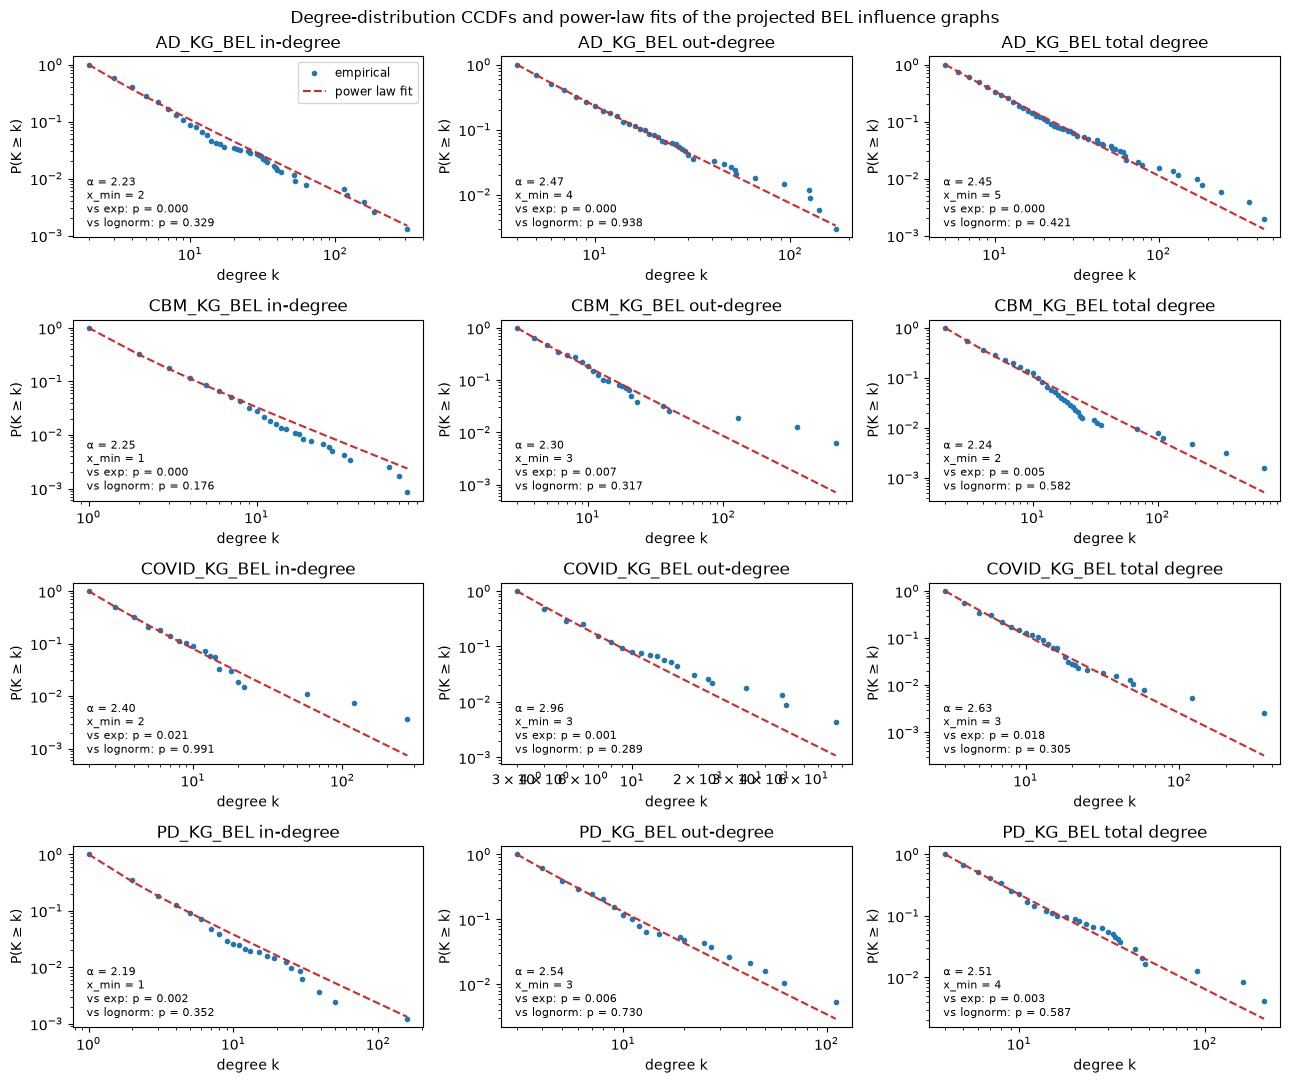

In [36]:
import warnings

import matplotlib.pyplot as plt

scale_free_records = []
fits = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # powerlaw is chatty about xmin / divide-by-zero
    for collection_name in BEL_COLLECTIONS:
        collection_degrees = degree_df[degree_df["collection_name"] == collection_name]
        for degree_column, degree_label in DEGREE_TYPES:
            result = fit_degree_power_law(collection_degrees[degree_column].to_numpy())
            fits[(collection_name, degree_column)] = result.pop("_fit")
            scale_free_records.append(
                {"collection_name": collection_name, "degree": degree_label, **result}
            )
scale_free_df = pd.DataFrame(scale_free_records)

# One KG per row, one degree type per column: empirical CCDF + fitted power law tail.
figure, axes = plt.subplots(
    len(BEL_COLLECTIONS), len(DEGREE_TYPES), figsize=(13, 11), squeeze=False
)
for row, collection_name in enumerate(BEL_COLLECTIONS):
    for column, (degree_column, degree_label) in enumerate(DEGREE_TYPES):
        axis = axes[row][column]
        fit = fits[(collection_name, degree_column)]
        fit.plot_ccdf(
            ax=axis, color="tab:blue", marker=".", linestyle="none", label="empirical"
        )
        fit.power_law.plot_ccdf(
            ax=axis, color="tab:red", linestyle="--", label="power law fit"
        )
        parameters = scale_free_df[
            (scale_free_df["collection_name"] == collection_name)
            & (scale_free_df["degree"] == degree_label)
        ].iloc[0]
        axis.set_title(f"{collection_name} {degree_label}")
        axis.set_xlabel("degree k")
        axis.set_ylabel("P(K ≥ k)")
        axis.text(
            0.04,
            0.04,
            f"α = {parameters['alpha']:.2f}\n"
            f"x_min = {parameters['x_min']:.0f}\n"
            f"vs exp: p = {parameters['p_vs_exponential']:.3f}\n"
            f"vs lognorm: p = {parameters['p_vs_lognormal']:.3f}",
            transform=axis.transAxes,
            va="bottom",
            ha="left",
            fontsize=8,
        )
        if row == 0 and column == 0:
            axis.legend(fontsize="small", loc="upper right")
figure.suptitle(
    "Degree-distribution CCDFs and power-law fits of the projected BEL influence graphs"
)
figure.tight_layout()
plt.show()

# Fit results pivoted: one row per fit parameter, one column per (KG, degree).
PARAMETER_ORDER = [
    "n_nonzero_nodes",
    "alpha",
    "x_min",
    "n_tail",
    "R_vs_exponential",
    "p_vs_exponential",
    "R_vs_lognormal",
    "p_vs_lognormal",
]
scale_free_table = (
    scale_free_df.melt(id_vars=["collection_name", "degree"], var_name="parameter")
    .pivot(index="parameter", columns=["collection_name", "degree"], values="value")
    .reindex(PARAMETER_ORDER)
    .reindex(
        columns=pd.MultiIndex.from_product(
            [BEL_COLLECTIONS, [label for _, label in DEGREE_TYPES]]
        )
    )
)
stripe_table(
    scale_free_table,
    column_colors=("#d6eaf8", "#d5f0dc", "#fce8d5"),
)

##### Degree distributions comparison

We compare the four KGs' in, out and total degree distributions pairwise with the two-sample Kolmogorov–Smirnov statistic $D = \max_k \left| F_1(k) - F_2(k) \right|$.<br>
This is the largest gap between two empirical cumulative degree distributions, from $0$ (identical) to $1$ (disjoint), and it is independent of how many nodes each KG has.<br>
Here, p-values are meaningless, since each KG is essentially a whole graph rather than a sample, and at this $n$ any non-zero difference comes out "significant".

In [37]:
import itertools

from scipy import stats


def get_bel_degree_ks_comparison(degree_df):
    """Pairwise two-sample Kolmogorov–Smirnov comparison of the projected
    influence-graph degree distributions between BEL collections, for in-, out-
    and total degree. Returns one row per (collection pair, degree type) with the
    KS statistic ``D``."""
    rows = [
        {
            "collection_name_1": first,
            "collection_name_2": second,
            "degree": degree_label,
            "D": stats.ks_2samp(
                degree_df.loc[degree_df["collection_name"] == first, degree_column],
                degree_df.loc[degree_df["collection_name"] == second, degree_column],
            ).statistic,
        }
        for first, second in itertools.combinations(BEL_COLLECTIONS, 2)
        for degree_column, degree_label in DEGREE_TYPES
    ]
    return pd.DataFrame(
        rows, columns=["collection_name_1", "collection_name_2", "degree", "D"]
    )


def get_bel_degree_ks_matrix(ks_df, degree_label):
    """Symmetric matrix of the KS statistic ``D`` between BEL collections for one
    degree type, collections on both axes (0 on the diagonal)."""
    matrix = pd.DataFrame(0.0, index=BEL_COLLECTIONS, columns=BEL_COLLECTIONS)
    for row in ks_df[ks_df["degree"] == degree_label].itertuples():
        matrix.loc[row.collection_name_1, row.collection_name_2] = row.D
        matrix.loc[row.collection_name_2, row.collection_name_1] = row.D
    return matrix

In [38]:
from IPython.display import Markdown, display

bel_degree_ks_df = get_bel_degree_ks_comparison(degree_df)
for _, degree_label in DEGREE_TYPES:
    display(Markdown(f"**{degree_label}**"))
    display(
        stripe_table(
            get_bel_degree_ks_matrix(bel_degree_ks_df, degree_label),
            column_colors=(None,),
        )
    )

**in-degree**

,AD_KG_BEL,CBM_KG_BEL,COVID_KG_BEL,PD_KG_BEL
AD_KG_BEL,0.00,0.14,0.09,0.05
CBM_KG_BEL,0.14,0.00,0.23,0.15
COVID_KG_BEL,0.09,0.23,0.00,0.08
PD_KG_BEL,0.05,0.15,0.08,0.00


**out-degree**

,AD_KG_BEL,CBM_KG_BEL,COVID_KG_BEL,PD_KG_BEL
AD_KG_BEL,0.00,0.27,0.05,0.06
CBM_KG_BEL,0.27,0.00,0.23,0.22
COVID_KG_BEL,0.05,0.23,0.00,0.07
PD_KG_BEL,0.06,0.22,0.07,0.00


**total degree**

,AD_KG_BEL,CBM_KG_BEL,COVID_KG_BEL,PD_KG_BEL
AD_KG_BEL,0.00,0.13,0.08,0.08
CBM_KG_BEL,0.13,0.00,0.13,0.05
COVID_KG_BEL,0.08,0.13,0.00,0.08
PD_KG_BEL,0.08,0.05,0.08,0.00


#### Path lengths and connectivity

We analyse connected components and path length within them, both considering undirected and directed edges:

- `n_nodes`: number of nodes
- `n_weak_components`: number of connected components
- `largest_component_fraction`: fraction of nodes in the largest connected component (LCC)
- `undirected_average_path`: mean shortest-path length within the LCC, edges undirected
- `directed_reachable_fraction`: fraction of ordered node pairs linked by a directed path
- `directed_average_path`: mean shortest-path length over directed-reachable pairs

In [39]:
import networkx as nx


def get_bel_path_length_stats(projection):
    """Connectivity and shortest-path statistics of each projected influence
    graph, undirected and directed.

    Undirected (an edge is one hop, ignoring causal direction) gives the
    characteristic path length, measured on the largest connected component
    (LCC); ``largest_component_fraction`` is its node coverage and ``n_weak_components`` the
    number of components. Directed (following edge direction) averages only over
    the ordered node pairs reachable by a directed path, with
    ``directed_reachable_fraction`` the share of the n*(n-1) ordered pairs
    reachable."""
    rows = []
    for collection_name, graph in projection.items():
        n_nodes = graph.number_of_nodes()
        undirected = graph.to_undirected()
        components = list(nx.connected_components(undirected))
        largest_component = undirected.subgraph(max(components, key=len)).copy()
        directed_lengths = [
            length
            for _, lengths in nx.all_pairs_shortest_path_length(graph)
            for length in lengths.values()
            if length > 0
        ]
        n_ordered_pairs = n_nodes * (n_nodes - 1)
        rows.append(
            {
                "collection_name": collection_name,
                "n_nodes": n_nodes,
                "n_weak_components": len(components),
                "largest_component_fraction": round(
                    largest_component.number_of_nodes() / n_nodes, 3
                ),
                "undirected_average_path": round(
                    nx.average_shortest_path_length(largest_component), 3
                ),
                "directed_reachable_fraction": round(
                    len(directed_lengths) / n_ordered_pairs, 3
                ),
                "directed_average_path": round(
                    sum(directed_lengths) / len(directed_lengths), 3
                ),
            }
        )
    return pd.DataFrame(rows)

In [40]:
path_length_df = get_bel_path_length_stats(bel_projection)
stripe_table(path_length_df)

,collection_name,n_nodes,n_weak_components,largest_component_fraction,undirected_average_path,directed_reachable_fraction,directed_average_path
0,AD_KG_BEL,2796,112,0.88,4.19,0.15,4.63
1,PD_KG_BEL,1315,75,0.80,4.96,0.07,4.24
2,COVID_KG_BEL,1176,82,0.74,5.18,0.02,2.68
3,CBM_KG_BEL,1515,35,0.92,3.61,0.11,4.60


#### Phenotype-hub dependence of paths

A path through a phenotype (biological process or pathology) can't represent a molecular mechanism.<br>
We compute how many directed reachable pairs are not reachable anymore when removing phenotype hubs from the graph:

- `degree_percentile`: percentile of phenotype node degrees defining the hub cutoff
- `degree_threshold`: the degree at that percentile
- `n_hubs`: number of phenotype hubs removed
- `hub_dependent_fraction`: fraction of directed-reachable non-hub pairs become unreachable after removing the hubs

In [41]:
import networkx as nx
import numpy as np


def get_bel_phenotype_hub_dependence(projection, percentiles=(90, 95, 99)):
    """For each projected influence graph, the fraction of connectable pairs that
    can only be connected through a phenotype/pathology hub.

    Phenotype/pathology hubs are the phenotype nodes above the given percentile of
    the phenotype-node degree distribution. ``hub_dependent_fraction`` is the share
    of directed-reachable ordered pairs of non-hub nodes that become unreachable once
    the hubs are removed -- i.e. pairs with no hub-free directed path, whose only
    route runs through a promiscuous phenotype node."""
    rows = []
    for collection_name, graph in projection.items():
        degrees = {node: graph.degree(node) for node in graph}
        phenotype_degrees = [
            degrees[node]
            for node in graph
            if graph.nodes[node]["node_class"] in PHENOTYPE_NODE_TYPES
        ]
        for percentile in percentiles:
            threshold = float(np.percentile(phenotype_degrees, percentile))
            hubs = {
                node
                for node in graph
                if graph.nodes[node]["node_class"] in PHENOTYPE_NODE_TYPES
                and degrees[node] > threshold
            }
            non_hubs = [node for node in graph if node not in hubs]
            reachable_before = sum(
                len(nx.descendants(graph, source) - hubs) for source in non_hubs
            )
            pruned = graph.subgraph(non_hubs)
            reachable_after = sum(
                len(nx.descendants(pruned, source)) for source in non_hubs
            )
            rows.append(
                {
                    "collection_name": collection_name,
                    "degree_percentile": percentile,
                    "degree_threshold": round(threshold, 1),
                    "n_hubs": len(hubs),
                    "hub_dependent_fraction": round(
                        1 - reachable_after / reachable_before, 3
                    )
                    if reachable_before
                    else float("nan"),
                }
            )
    return pd.DataFrame(rows)

In [42]:
hub_dependence_df = get_bel_phenotype_hub_dependence(bel_projection)
stripe_table(hub_dependence_df.set_index(["collection_name", "degree_percentile"]))